In [105]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
)



# **STEP 1: Load and Split Dataset**

In [107]:

df = pd.read_csv("/content/Group Work_Pipeline_Last.csv")

In [108]:
#Display First Five Rows
display(df.head())

,age,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,is_fit,encoded_gender,encoded_smokes,BMI
0,0.622951,0.429319,0.390738,0.492958,0.237,0.744361,1,0,0,0.438029
1,0.836066,0.275742,0.358900,0.492958,0.877,0.548872,1,0,0,0.422732
2,0.459016,0.286213,0.382055,0.492958,0.820,0.258145,0,0,0,0.433645
3,0.229508,0.265271,0.580318,0.422535,0.618,0.671679,1,1,0,0.326838
4,0.688525,0.228621,0.373372,0.563380,0.995,0.959900,1,0,1,0.533212


In [109]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1953 entries, 0 to 1952
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1953 non-null   float64
 1   heart_rate         1953 non-null   float64
 2   blood_pressure     1953 non-null   float64
 3   sleep_hours        1953 non-null   float64
 4   nutrition_quality  1953 non-null   float64
 5   activity_index     1953 non-null   float64
 6   is_fit             1953 non-null   int64  
 7   encoded_gender     1953 non-null   int64  
 8   encoded_smokes     1953 non-null   int64  
 9   BMI                1953 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 152.7 KB


In [110]:
# Separate features and target
X = df.drop(columns=['is_fit'])
y = df['is_fit']



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print(" Dataset Shapes:")
print(f"Total Dataset Shape: {df.shape}")
print(f"Feature Matrix (X) Shape: {X.shape}")
print(f"Target Vector (y) Shape: {y.shape}")
print(f"Training Set Shape: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing Set Shape:  X_test  = {X_test.shape}, y_test  = {y_test.shape}\n")

 Dataset Shapes:
Total Dataset Shape: (1953, 10)
Feature Matrix (X) Shape: (1953, 9)
Target Vector (y) Shape: (1953,)
Training Set Shape: X_train = (1562, 9), y_train = (1562,)
Testing Set Shape:  X_test  = (391, 9), y_test  = (391,)



# **STEP 2: Manual Training for Best K**


Best K found using training data CV: 18

Final Model Results on Test Data
Best K Value      : 18
Training Accuracy : 0.7913
Test Accuracy     : 0.7519
Metric            : euclidean
Weights           : uniform
F1 Score          : 0.6523
Precision         : 0.7398
Recall            : 0.5833
ROC-AUC           : 0.8142
 


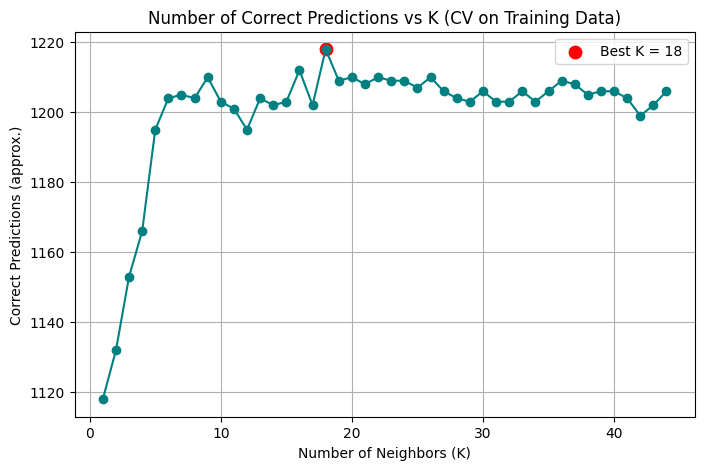

In [111]:

# Input parameters
metric_type = 'euclidean'
weight_type = 'uniform'


# Find Best K using training data CV
k_values = range(1, 45)
cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, metric=metric_type, weights=weight_type)
    # 5-fold cross-validation on training data
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k_index = np.argmax(cv_scores)
best_k = k_values[best_k_index]

print(f"Best K found using training data CV: {best_k}")


#Train Final Model with Best K
best_model = KNeighborsClassifier(n_neighbors=best_k, metric=metric_type, weights=weight_type)
best_model.fit(X_train, y_train)
pred_test = best_model.predict(X_test)


#Calculate Metrics on Test Data
train_acc = best_model.score(X_train, y_train)
test_acc = accuracy_score(y_test, pred_test)
f1 = f1_score(y_test, pred_test)
precision = precision_score(y_test, pred_test)
recall = recall_score(y_test, pred_test)
roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
cm = confusion_matrix(y_test, pred_test)


# Print Results
print("\nFinal Model Results on Test Data")
print(f"Best K Value      : {best_k}")
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Metric            : {metric_type}")
print(f"Weights           : {weight_type}")
print(f"F1 Score          : {f1:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(" ")


#Plot Correct Predictions vs K (Training CV)
correct_cv = [int(score * len(X_train)) for score in cv_scores]

plt.figure(figsize=(8,5))
plt.plot(k_values, correct_cv, marker='o', color='teal')
plt.title('Number of Correct Predictions vs K (CV on Training Data)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Correct Predictions (approx.)')
plt.grid(True)

# Highlight the best K
best_correct_cv = correct_cv[best_k_index]
plt.scatter(best_k, best_correct_cv, color='red', s=80, label=f'Best K = {best_k}')
plt.legend()
plt.show()


# **STEP 3: Manual KNN Training (User Input for K)**

In [112]:

# Manually assigned parameters
k_manual = 20
metric_manual = 'euclidean'
weight_manual = 'uniform'

manual_knn = KNeighborsClassifier(n_neighbors=k_manual, metric=metric_manual, weights=weight_manual)

#Cross-validation on Training Data
cv_scores_manual = cross_val_score(manual_knn, X_train, y_train, cv=5, scoring='accuracy')
manual_cv_acc = cv_scores_manual.mean()
print(f"Manual K = {k_manual} | Metric = {metric_manual} | Weights = {weight_manual}")
print(f"Cross-Validation Accuracy (Training): {manual_cv_acc:.4f}")

# Fit on full training data
manual_knn.fit(X_train, y_train)

# Predictions
y_manual_pred_train = manual_knn.predict(X_train)
y_manual_pred_test = manual_knn.predict(X_test)

# Evaluation metrics
manual_train_acc = accuracy_score(y_train, y_manual_pred_train)
manual_test_acc = accuracy_score(y_test, y_manual_pred_test)
manual_f1 = f1_score(y_test, y_manual_pred_test)
manual_precision = precision_score(y_test, y_manual_pred_test)
manual_recall = recall_score(y_test, y_manual_pred_test)
manual_cm = confusion_matrix(y_test, y_manual_pred_test)
manual_roc = roc_auc_score(y_test, manual_knn.predict_proba(X_test)[:, 1])

#Print results
print(f"\nManual Evaluation Metrics:")
print(f"Training Accuracy      : {manual_train_acc:.4f}")
print(f"Cross-Validation Acc   : {manual_cv_acc:.4f}")
print(f"Test Accuracy          : {manual_test_acc:.4f}")
print(f"F1 Score               : {manual_f1:.4f}")
print(f"Precision              : {manual_precision:.4f}")
print(f"Recall                 : {manual_recall:.4f}")
print(f"ROC-AUC                : {manual_roc:.4f}")



Manual K = 20 | Metric = euclidean | Weights = uniform
Cross-Validation Accuracy (Training): 0.7753

Manual Evaluation Metrics:
Training Accuracy      : 0.7945
Cross-Validation Acc   : 0.7753
Test Accuracy          : 0.7596
F1 Score               : 0.6594
Precision              : 0.7583
Recall                 : 0.5833
ROC-AUC                : 0.8150


# **STEP 4: Automatic Best KNN using GridSearchCV**

In [113]:
param_grid = {
    'n_neighbors': range(1, 45),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_

# Predictions
y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

# Predictions for automatic/best KNN
y_pred = best_knn.predict(X_test)

# Metrics calculation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)
cv_f1 = cross_val_score(best_knn, X_train, y_train, cv=5, scoring='f1').mean()
cm = confusion_matrix(y_test, y_pred)


# Print results in desired format
print("\n Automatic Model Performance Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print("Confusion Matrix:")

print(f"Mean CV F1 Score: {cv_f1:.4f}")


# Print best hyperparameters
print("\nBest Hyperparameters selected by GridSearchCV:")
print(grid_search.best_params_)



 Automatic Model Performance Metrics:
Accuracy: 0.7289
F1 Score: 0.6345
Precision: 0.6866
Recall: 0.5897
ROC-AUC: 0.7055
Confusion Matrix:
Mean CV F1 Score: 0.7138

Best Hyperparameters selected by GridSearchCV:
{'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'distance'}


# **STEP 5: Manual vs Automatic Comparison**

In [114]:
# Cross-Validation F1 Scores
manual_cv_f1 = cross_val_score(manual_knn, X_train, y_train, cv=5, scoring='f1').mean()
auto_cv_f1 = cross_val_score(best_knn, X_train, y_train, cv=5, scoring='f1').mean()
best_k_cv_f1 = cross_val_score(
    KNeighborsClassifier(n_neighbors=best_k, metric=metric_type, weights=weight_type),
    X_train, y_train, cv=5, scoring='f1'
).mean()


print("\n Manual KNN Parameters ")
print(f"{'Metric':<20} {metric_type}")
print(f"{'Weights':<20} {weight_type}")


# Print Best K Metrics
print("\n Best K Value Metrics ")
print(f"{'Metric':<20} {'Value':<10}")
print(f"{'-'*30}")
print(f"{'Best K':<20} {best_k:<10}")
print(f"{'Training Accuracy':<20} {train_acc:.4f}")
print(f"{'Test Accuracy':<20} {test_acc:.4f}")
print(f"{'F1 Score':<20} {f1:.4f}")
print(f"{'Precision':<20} {precision:.4f}")
print(f"{'Recall':<20} {recall:.4f}")
print(f"{'ROC-AUC':<20} {roc_auc:.4f}")
print(f"{'CV F1 Score':<20} {best_k_cv_f1:.4f}")

#Print Manual KNN Metrics
print("\n Manual KNN Metrics ")
print(f"{'Metric':<20} {'Value':<10}")
print(f"{'-'*30}")
print(f"{'K':<20} {k_manual}")
print(f"{'Training Accuracy':<20} {manual_train_acc:.4f}")
print(f"{'Test Accuracy':<20} {manual_test_acc:.4f}")
print(f"{'F1 Score':<20} {manual_f1:.4f}")
print(f"{'Precision':<20} {manual_precision:.4f}")
print(f"{'Recall':<20} {manual_recall:.4f}")
print(f"{'ROC-AUC':<20} {manual_roc:.4f}")
print(f"{'CV F1 Score':<20} {manual_cv_f1:.4f}")



#Print Automatic KNN Metrics
print("\n Automatic KNN Metrics (GridSearchCV) ")
print(f"{'Metric':<20} {'Value':<10}")
print(f"{'-'*30}")
print(f"{'K':<20} {grid_search.best_params_['n_neighbors']}")
print(f"{'Training Accuracy':<20} {grid_search.best_estimator_.score(X_train, y_train):.4f}")
print(f"{'Test Accuracy':<20} {acc:.4f}")
print(f"{'F1 Score':<20} {f1:.4f}")
print(f"{'Precision':<20} {prec:.4f}")
print(f"{'Recall':<20} {rec:.4f}")
print(f"{'ROC-AUC':<20} {roc:.4f}")
print(f"{'CV F1 Score':<20} {auto_cv_f1:.4f}")

# Print best hyperparameters
print("\nBest Hyperparameters selected by GridSearchCV:")
print(grid_search.best_params_)


 Manual KNN Parameters 
Metric               euclidean
Weights              uniform

 Best K Value Metrics 
Metric               Value     
------------------------------
Best K               18        
Training Accuracy    0.7913
Test Accuracy        0.7519
F1 Score             0.6345
Precision            0.7398
Recall               0.5833
ROC-AUC              0.8142
CV F1 Score          0.7010

 Manual KNN Metrics 
Metric               Value     
------------------------------
K                    20
Training Accuracy    0.7945
Test Accuracy        0.7596
F1 Score             0.6594
Precision            0.7583
Recall               0.5833
ROC-AUC              0.8150
CV F1 Score          0.6933

 Automatic KNN Metrics (GridSearchCV) 
Metric               Value     
------------------------------
K                    10
Training Accuracy    1.0000
Test Accuracy        0.7289
F1 Score             0.6345
Precision            0.6866
Recall               0.5897
ROC-AUC              0.7055


 **Confusion Matrix**

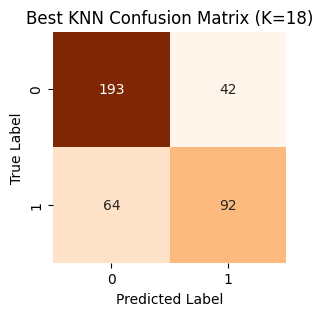

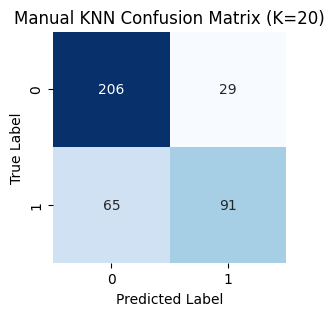

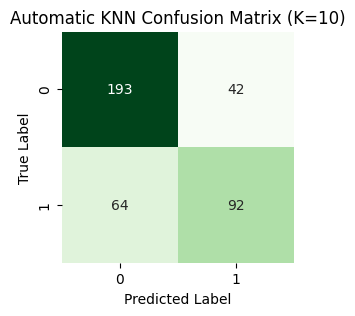

In [115]:
# Manual KNN for best k Confusion Matrix Plot
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)  # Use heatmap for consistent style
plt.title(f'Best KNN Confusion Matrix (K={best_k})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Manual KNN Confusion Matrix Plot
plt.figure(figsize=(3,3))
sns.heatmap(manual_cm, annot=True, fmt='d', cmap='Blues', cbar=False)  # cbar=False removes color bar
plt.title(f'Manual KNN Confusion Matrix (K={k_manual})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Automatic KNN Confusion Matrix Plot
auto_cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(3,3))
sns.heatmap(auto_cm, annot=True, fmt='d', cmap='Greens', cbar=False)  # cbar=False removes color bar
plt.title(f'Automatic KNN Confusion Matrix (K={grid_search.best_params_["n_neighbors"]})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



**ROC Curve**

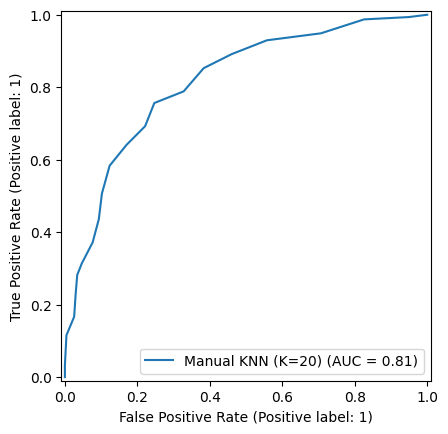

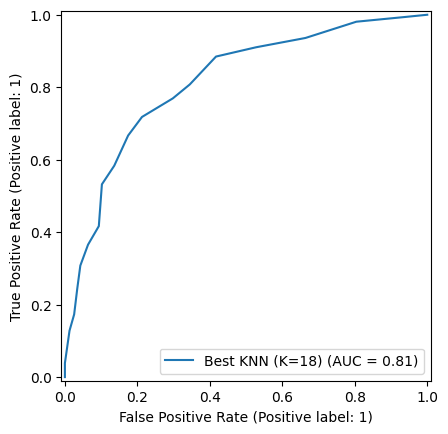

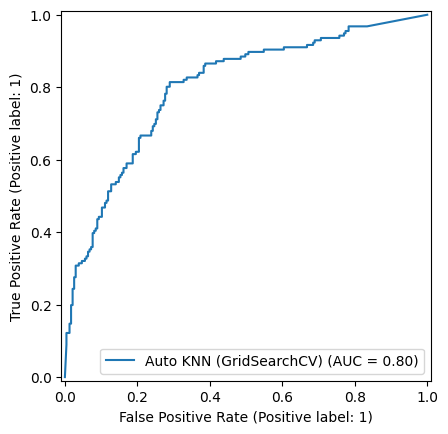

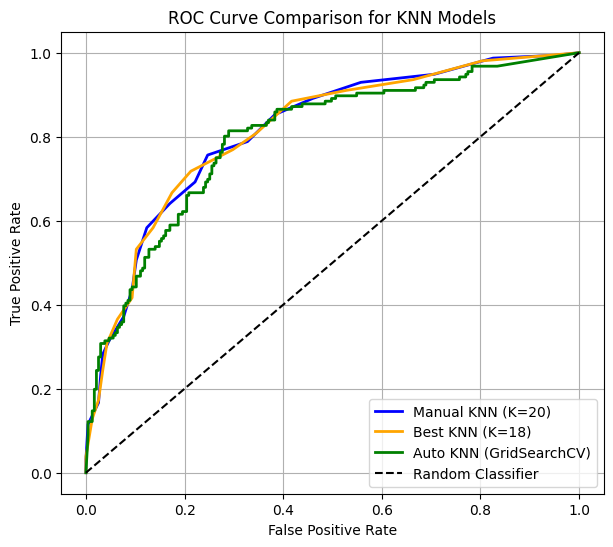

In [116]:
# ROC Curve Comparison ---
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Generate ROC curve data for each model
manual_roc_display = RocCurveDisplay.from_estimator(
    manual_knn, X_test, y_test, name=f'Manual KNN (K={k_manual})'
)
best_roc_display = RocCurveDisplay.from_estimator(
    best_model, X_test, y_test, name=f'Best KNN (K={best_k})'
)
auto_roc_display = RocCurveDisplay.from_estimator(
    best_knn, X_test, y_test, name='Auto KNN (GridSearchCV)'
)

# Plot ROC curves together
plt.figure(figsize=(7,6))
plt.plot(manual_roc_display.fpr, manual_roc_display.tpr, label=f'Manual KNN (K={k_manual})', color='blue', linewidth=2)
plt.plot(best_roc_display.fpr, best_roc_display.tpr, label=f'Best KNN (K={best_k})', color='orange', linewidth=2)
plt.plot(auto_roc_display.fpr, auto_roc_display.tpr, label='Auto KNN (GridSearchCV)', color='green', linewidth=2)

# Reference line for random guessing
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

# Formatting
plt.title('ROC Curve Comparison for KNN Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()